# Engenharia de Dados para RFM

**Objetivo:** Construir a base consolidada RFM (Recência, Frequência, Valor Monetário) a partir de `df_limpo.txt`,
calcular os scores (r_score, f_score, m_score) e salvar a base final pronta para análise/segmentação.

Notebook organizado para portfólio profissional: documentação, boas práticas e visualizações.


In [9]:
# 1) Preparação e importações
import os
from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Visual style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")

# Mostrar mais linhas/colunas se necessário
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 160)

print("Bibliotecas importadas. Ambiente pronto.")


Bibliotecas importadas. Ambiente pronto.


## 2) Carregamento do arquivo `df_limpo.txt`

O notebook tentará carregar o arquivo no caminho especificado. Se preferir, altere `input_path` ou
carregue `df_limpo` manualmente no ambiente antes de executar.


In [10]:
# 2) Carregamento do df_limpo
input_path = r"outputs\df_limpo.csv"

print("Tentando carregar:", input_path)
p = Path(input_path)
if not p.exists():
    raise FileNotFoundError(f"Arquivo não encontrado: {input_path}\nVerifique o caminho e tente novamente.")
    
# Leitura (tabulado)
df = pd.read_csv(p)
print("Arquivo carregado com sucesso. Shape:", df.shape)
display(df.head())



Tentando carregar: outputs\df_limpo.csv
Arquivo carregado com sucesso. Shape: (552250, 25)


,id_cliente,nome_cliente,sexo,idade,estado_civil,renda_mensal,cidade,estado,canal_compra,categoria_produto,valor_compra,frequencia_compras,score_fidelidade,data_ultima_compra,método_pagamento,tempo_cliente,desconto_medio,participa_programa_fidelidade,resposta_campanha_marketing,satisfacao_cliente,canal_preferido,prob_churn,n_itens_por_compra,classe_socioeconomica,dispositivo_utilizado
0,CLI_000001,Bruna Carvalho Pereira,Outro,25,solteiro,1139.54,Rio de Janeiro,Rio de Janeiro,loja física,carnes,103.12,0.4,0.0,2024-12-28,débito,1,12.6,Sim,Sim,3.2,loja física,0.640,11.0,D,tablet
1,CLI_000002,Antônia Nascimento Martins,F,55,divorciado,1805.82,Caruaru,Pernambuco,site,cerveja,63.79,0.9,9.5,2024-12-10,débito,6,21.2,Não,Sim,3.6,site,0.529,11.2,D,tablet
2,CLI_000003,Pedro Dias Lima,M,53,divorciado,1861.71,Juazeiro,Bahia,loja física,snack,291.10,1.0,3.0,2024-11-25,boleto,3,9.5,Não,Não,9.0,loja física,0.584,3.3,D,desktop
3,CLI_000004,Patrícia Oliveira Alves,Outro,77,solteiro,2684.55,Guarulhos,São Paulo,loja física,cosmético,65.00,1.9,24.5,2024-12-27,Pix,9,19.4,Sim,Sim,7.8,loja física,0.449,12.3,C2,desktop
4,CLI_000005,Andréa Lopes Oliveira,Outro,74,divorciado,3996.93,Cidade_83,Rondônia,app,frutas,63.93,2.5,25.5,2024-12-24,débito,3,10.7,Não,Não,6.8,app,0.387,4.1,C1,mobile


### Validação das colunas necessárias

Verificamos se as colunas essenciais para construir RFM estão presentes:
- `id_cliente`
- `valor_compra`
- `frequencia_compras`
- `recencia_dias` ou `data_ultima_compra`


In [11]:
# 2.1 Validação de colunas obrigatórias
required = ['id_cliente', 'valor_compra', 'frequencia_compras']
if not all(col in df.columns for col in required):
    missing = [c for c in required if c not in df.columns]
    raise ValueError(f"Colunas obrigatórias ausentes: {missing}")

# Para recência: preferimos usar data_ultima_compra se existir, senão recencia_dias
has_date = 'data_ultima_compra' in df.columns
has_recencia = 'recencia_dias' in df.columns

if not (has_date or has_recencia):
    raise ValueError("É necessário ter 'data_ultima_compra' ou 'recencia_dias' na base para calcular recência.")

print("Validação concluída. Colunas obrigatórias presentes.")


Validação concluída. Colunas obrigatórias presentes.


## 3) Funções auxiliares

Funções para:
- Converter data,
- Calcular recência quando necessário,
- Tratar duplicidades e validar `id_cliente`.


In [12]:
# 3.1 Funções auxiliares

def ensure_datetime(df, col):
    """Converte coluna para datetime (coerce para NaT em valores inválidos)."""
    df[col] = pd.to_datetime(df[col], errors='coerce')
    return df

def compute_reference_date(df, date_col='data_ultima_compra'):
    """Retorna data referência (max + 1 dia) a ser usada para recência."""
    ref = df[date_col].max()
    if pd.isna(ref):
        raise ValueError("data_ultima_compra contém apenas NaT. Não é possível definir data_referencia.")
    return ref + pd.Timedelta(days=1)

def check_duplicate_ids(df, id_col='id_cliente'):
    """Relata duplicidade de IDs e retorna número de IDs únicos vs registros."""
    total = len(df)
    unique_ids = df[id_col].nunique()
    dup_count = total - unique_ids
    print(f"Registros: {total:,} | IDs únicos: {unique_ids:,} | Registros duplicados: {dup_count:,}")
    return dup_count


## 4) Construção dos indicadores RFM

- Valor monetário: soma de `valor_compra` por cliente.
- Frequência: contagem de compras por cliente.
- Recência: dias desde a última compra (menor é melhor).


In [22]:
# 4.1 Preparar recência
if has_date:
    df = ensure_datetime(df, 'data_ultima_compra')
    data_referencia = compute_reference_date(df, 'data_ultima_compra')
    print("Data referência definida como:", data_referencia.date())
    # criar coluna recencia_calculada em dias
    df['recencia_calculada'] = (data_referencia - df['data_ultima_compra']).dt.days
else:
    # usa recencia_dias já existente
    df['recencia_calculada'] = df['recencia_dias']
    print("Usando recencia_dias da base para recência calculada.")

# 4.2 Checar duplicidade de id_cliente
check_duplicate_ids(df, 'id_cliente')

# 4.3 Agregar por id_cliente
rfm_agg = (
    df.groupby('id_cliente')
      .agg(valor_monetario=('valor_compra', 'sum'),
           frequencia=('frequencia_compras', 'last'),#Considerar uso de Max
           recencia=('recencia_calculada', 'min'))  # menor recência (mais recente)
      .reset_index()
)

print("Base RFM agregada. Shape:", rfm_agg.shape)
print("\nAmostra dos dados agregados:")
display(rfm_agg.head())


Data referência definida como: 2025-01-01
Registros: 552,250 | IDs únicos: 552,250 | Registros duplicados: 0
Base RFM agregada. Shape: (552250, 4)

Amostra dos dados agregados:


,id_cliente,valor_monetario,frequencia,recencia
0,CLI_000001,103.12,0.4,4
1,CLI_000002,63.79,0.9,22
2,CLI_000003,291.10,1.0,37
3,CLI_000004,65.00,1.9,5
4,CLI_000005,63.93,2.5,8


## 5) Preparação para cálculo dos scores

- Remover (ou notificar) valores nulos em `valor_monetario`, `frequencia`, `recencia`.
- tratamento de zeros/negativos se fizer sentido.


In [23]:
# 5.1 Validar nulos e valores inválidos
print("Valores nulos por coluna (agregada):")
display(rfm_agg.isnull().sum())

# Remover linhas com NA nas colunas RFM (se houver)
n_before = len(rfm_agg)
rfm_agg = rfm_agg.dropna(subset=['valor_monetario','frequencia','recencia'])
n_after = len(rfm_agg)
print(f"Removidas {n_before - n_after} linhas com NA em R/F/M (se houver).")

# Reportar zeros/negativos importantes
for c in ['valor_monetario','frequencia','recencia']:
    n_zero = (rfm_agg[c] == 0).sum()
    n_neg = (rfm_agg[c] < 0).sum()
    if n_zero or n_neg:
        print(f"Atenção: coluna {c} contém {n_zero} zeros e {n_neg} valores negativos.")
rfm_agg.describe()

Valores nulos por coluna (agregada):


id_cliente         0
valor_monetario    0
frequencia         0
recencia           0
dtype: int64

Removidas 0 linhas com NA em R/F/M (se houver).


,valor_monetario,frequencia,recencia
count,552250.000000,552250.000000,552250.000000
mean,110.291330,2.367964,60.536494
std,64.631457,1.969499,60.002634
min,15.000000,0.100000,1.000000
25%,60.460000,0.900000,18.000000
50%,94.110000,1.800000,42.000000
75%,144.920000,3.200000,84.000000
max,307.890000,12.000000,782.000000


## 6) Cálculo dos Scores R, F e M (1-5) via quintis

Os scores R, F e M foram calculados por meio de **quintis** utilizando `pd.qcut`.
Para as métricas de **Frequência** e **Valor Monetário**, foi aplicado um ranking
prévio devido à presença de muitos valores repetidos, o que pode dificultar a
formação adequada dos quantis.

O uso do ranking garante uma distribuição equilibrada dos clientes entre os
scores, assegurando estabilidade e consistência na pontuação RFM.



In [ ]:
# 6.1 Criando scores R, F, M
rfm = rfm_agg.copy()

# R_score: recência (menor é melhor) -> invertido
# Para evitar erros de qcut com poucos valores ou valores iguais, usamos try/except
try:
    rfm['r_score'] = pd.qcut(rfm['recencia'], 5, labels=[5,4,3,2,1]).astype(int)
except Exception as e:
    # fallback: usar rank para quebrar empates
    print("pd.qcut em recencia falhou, usando rank como fallback:", e)
    rfm['r_rank'] = rfm['recencia'].rank(method='first')
    rfm['r_score'] = pd.qcut(rfm['r_rank'], 5, labels=[5,4,3,2,1]).astype(int)
    rfm.drop(columns=['r_rank'], inplace=True)

# F_score: maior frequencia -> melhor
rfm['f_rank'] = rfm['frequencia'].rank(method='first')
rfm['f_score'] = pd.qcut(rfm['f_rank'], 5, labels=[1,2,3,4,5]).astype(int)
rfm.drop(columns=['f_rank'], inplace=True)

# M_score: maior valor_monetario -> melhor
rfm['m_rank'] = rfm['valor_monetario'].rank(method='first')
rfm['m_score'] = pd.qcut(rfm['m_rank'], 5, labels=[1,2,3,4,5]).astype(int)
rfm.drop(columns=['m_rank'], inplace=True)

# RFM concatenado
rfm['rfm_score'] = rfm['r_score'].astype(str) + rfm['f_score'].astype(str) + rfm['m_score'].astype(str)

print("Scores calculados. Exemplo:")o
display(rfm.head(20))
print("\nDistribuição de r_score, f_score, m_score:")
display(rfm[['r_score','f_score','m_score']].describe())


Scores calculados. Exemplo:


,id_cliente,valor_monetario,frequencia,recencia,r_score,f_score,m_score,rfm_score
0,CLI_000001,103.12,0.4,4,5,1,3,513
1,CLI_000002,63.79,0.9,22,4,2,2,422
2,CLI_000003,291.10,1.0,37,3,2,5,325
3,CLI_000004,65.00,1.9,5,5,3,2,532
4,CLI_000005,63.93,2.5,8,5,4,2,542
5,CLI_000006,182.70,0.4,48,3,1,5,315
6,CLI_000007,137.13,1.7,6,5,3,4,534
7,CLI_000008,186.54,3.3,20,4,4,5,445
8,CLI_000009,50.35,3.2,89,2,4,1,241
9,CLI_000010,187.13,0.3,23,4,1,5,415



Distribuição de r_score, f_score, m_score:


,r_score,f_score,m_score
count,552250.000000,552250.000000,552250.000000
mean,3.012639,3.000000,3.000000
std,1.422789,1.414215,1.414215
min,1.000000,1.000000,1.000000
25%,2.000000,2.000000,2.000000
50%,3.000000,3.000000,3.000000
75%,4.000000,4.000000,4.000000
max,5.000000,5.000000,5.000000


### Definição dos Scores RFM — Uso de Quintis

Os scores R, F e M foram definidos utilizando **quintis**, em vez de intervalos fixos (*bins*), como estratégia para garantir uma distribuição mais equilibrada dos clientes entre as classes.

Em análises RFM, é comum que as métricas apresentem **distribuições assimétricas**, especialmente no caso de frequência e valor monetário. Nesses cenários, a utilização de *bins* fixos pode concentrar grande parte dos clientes em poucas faixas, reduzindo a capacidade de discriminação entre perfis distintos.

O uso de quintis permite que cada score represente aproximadamente a mesma proporção da base, tornando a segmentação mais estável, comparável e menos sensível a valores extremos. Essa abordagem também facilita análises longitudinais, pois evita a dependência de limites arbitrários que podem variar entre períodos ou bases diferentes.

Essa prática é amplamente adotada na literatura de **marketing analítico e CRM**, sendo recomendada como forma de padronizar a pontuação RFM e maximizar seu poder interpretativo.

**Referência**

HUGHES, Arthur M. *Strategic Database Marketing*. 2. ed. New York: McGraw-Hill, 1994.


In [32]:
# 6.2 Validações dos Scores RFM

# 1) Check de valores não nulos
cols_scores = ['r_score', 'f_score', 'm_score', 'rfm_score']
assert rfm[cols_scores].isnull().sum().sum() == 0, "Existem valores nulos nos scores RFM"

# 2) Check de range dos scores (1 a 5)
for c in ['r_score', 'f_score', 'm_score']:
    min_val, max_val = rfm[c].min(), rfm[c].max()
    assert min_val >= 1 and max_val <= 5, f"{c} fora do range esperado (1–5)"

# 3) Check de consistência do rfm_score concatenado
rfm_score_recalc = (
    rfm['r_score'].astype(str) +
    rfm['f_score'].astype(str) +
    rfm['m_score'].astype(str)
)

assert (rfm['rfm_score'] == rfm_score_recalc).all(), \
    "Inconsistência detectada entre rfm_score e scores individuais"

print("Validações concluídas com sucesso:")
print("✔ Scores sem valores nulos")
print("✔ Scores dentro do range 1–5")
print("✔ rfm_score consistente com r_score, f_score e m_score")


Validações concluídas com sucesso:
✔ Scores sem valores nulos
✔ Scores dentro do range 1–5
✔ rfm_score consistente com r_score, f_score e m_score


Após o cálculo dos scores RFM, foram realizadas validações adicionais para garantir
a integridade dos dados, incluindo verificação de valores nulos, checagem do
range esperado (1–5) e consistência entre o score concatenado e os scores
individuais.


## 7) Resumo e verificações rápidas

- Mostrar a distribuição dos scores.
- Checar possíveis problemas (clusters vazios de quantis, etc.).


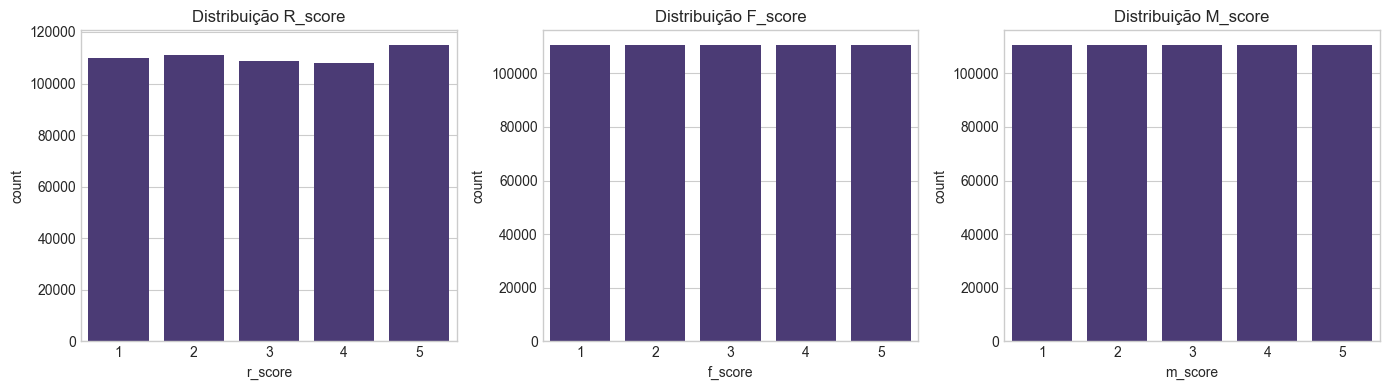

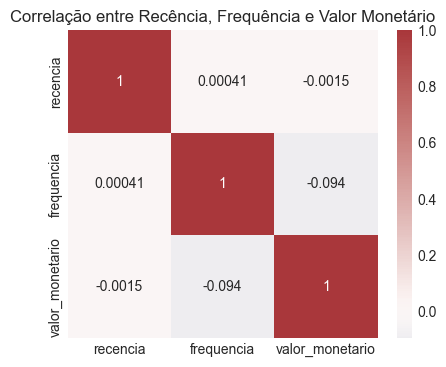

In [16]:
# 7.1 Distribuições de scores
fig, axes = plt.subplots(1,3, figsize=(14,4))
sns.countplot(x='r_score', data=rfm, ax=axes[0]).set_title('Distribuição R_score')
sns.countplot(x='f_score', data=rfm, ax=axes[1]).set_title('Distribuição F_score')
sns.countplot(x='m_score', data=rfm, ax=axes[2]).set_title('Distribuição M_score')
plt.tight_layout()
plt.show()

# 7.2 Heatmap das correlações entre valores R,F,M
corr = rfm[['recencia','frequencia','valor_monetario']].corr()
plt.figure(figsize=(5,4))
sns.heatmap(corr, annot=True, cmap='vlag', center=0)
plt.title('Correlação entre Recência, Frequência e Valor Monetário')
plt.show()


## Interpretação das Distribuições e Correlações RFM

As distribuições dos **scores R, F e M** apresentam comportamento equilibrado entre as classes de 1 a 5, o que indica que o processo de pontuação conseguiu dividir a base de clientes de forma homogênea. Esse resultado é esperado quando os scores são calculados a partir de quantis ou percentis e favorece comparações consistentes entre diferentes perfis de clientes.

A análise de correlação entre **Recência, Frequência e Valor Monetário** revela relações fracas entre as métricas, sugerindo que cada dimensão captura aspectos distintos do comportamento do cliente. Observa-se uma **correlação negativa entre Frequência e Valor Monetário**, ainda que de baixa magnitude, indicando que clientes mais frequentes tendem, em média, a realizar compras de menor valor individual.

Esse comportamento é comum em cenários de varejo, nos quais clientes recorrentes realizam compras menores e mais regulares, enquanto clientes menos frequentes concentram gastos em compras pontuais de maior valor. Já a recência apresenta correlação praticamente nula com as demais métricas, reforçando seu papel independente na identificação de clientes ativos ou inativos.


## 8) Montar a base final consolidada `rfm_final`

Colunas:
- id_cliente
- valor_monetario
- frequencia
- recencia
- r_score
- f_score
- m_score
- rfm_score (concatenado)


In [17]:
# 8.1 Construir rfm_final
rfm_final = rfm[['id_cliente','valor_monetario','frequencia','recencia','r_score','f_score','m_score','rfm_score']].copy()

print("Exemplo de registros finais:")
display(rfm_final.head())
print("\nResumo descritivo:")
display(rfm_final.describe().T)


Exemplo de registros finais:


,id_cliente,valor_monetario,frequencia,recencia,r_score,f_score,m_score,rfm_score
0,CLI_000001,103.12,0.4,4,5,1,3,513
1,CLI_000002,63.79,0.9,22,4,2,2,422
2,CLI_000003,291.10,1.0,37,3,2,5,325
3,CLI_000004,65.00,1.9,5,5,3,2,532
4,CLI_000005,63.93,2.5,8,5,4,2,542



Resumo descritivo:


,count,mean,std,min,25%,50%,75%,max
valor_monetario,552250.0,110.291330,64.631457,15.0,60.46,94.11,144.92,307.89
frequencia,552250.0,2.367964,1.969499,0.1,0.90,1.80,3.20,12.00
recencia,552250.0,60.536494,60.002634,1.0,18.00,42.00,84.00,782.00
r_score,552250.0,3.012639,1.422789,1.0,2.00,3.00,4.00,5.00
f_score,552250.0,3.000000,1.414215,1.0,2.00,3.00,4.00,5.00
m_score,552250.0,3.000000,1.414215,1.0,2.00,3.00,4.00,5.00


## 9) Salvar a base final nos formatos, .csv.


In [30]:
from pathlib import Path

# 9) Salvar outputs (formato CSV)
out_dir = Path("outputs")
out_dir.mkdir(exist_ok=True)

path_csv = out_dir / "rfm_final.csv"

rfm_final.to_csv(path_csv, index=False)

print(f"Arquivo salvo com sucesso: {path_csv}")



Arquivo salvo com sucesso: outputs\rfm_final.csv


## 10) Boas práticas e próximos passos (para o portfólio)

- Documente a lógica e as decisões (por exemplo: por que usar quintis, como tratar zeros/outliers).
- Adicione uma célula com testes/asserts (ex.: garantir que não há IDs duplicados em `rfm_final`).
- Transforme o notebook em funções reutilizáveis ou scripts para produção.
- Versione no GitHub com um README que explique o pipeline.


In [19]:
# Checks finais
#  - Não deve haver ids duplicados
dup_ids = rfm_final['id_cliente'].duplicated().sum()
assert dup_ids == 0, f"Existem {dup_ids} ids duplicados em rfm_final!"

print("Checks finais OK: sem IDs duplicados.")
print("Número de clientes na base RFM:", rfm_final['id_cliente'].nunique())


Checks finais OK: sem IDs duplicados.
Número de clientes na base RFM: 552250


##  Exportar Log de Execução
Gera um arquivo `rfm_exec_log.txt` com resumo das etapas executadas, data e hora.

In [33]:
# Geração do log de execução

from pathlib import Path
import datetime

log_path = Path("./rfm_exec_log.txt")

now = datetime.datetime.now()

with open(log_path, "w", encoding="utf-8") as f:
    f.write("LOG DE EXECUÇÃO - ENGENHARIA RFM\n")
    f.write(f"Data/Hora de execução: {now.strftime('%Y-%m-%d %H:%M:%S')}\n\n")

    # Informações gerais
    f.write("Resumo da execução:\n")
    f.write(f"- Total de clientes processados: {rfm.shape[0]:,}\n\n")

    # Estatísticas resumidas dos scores
    f.write("Estatísticas dos Scores RFM:\n")
    f.write(
        f"- R_score: min={rfm['r_score'].min()} | max={rfm['r_score'].max()}\n"
    )
    f.write(
        f"- F_score: min={rfm['f_score'].min()} | max={rfm['f_score'].max()}\n"
    )
    f.write(
        f"- M_score: min={rfm['m_score'].min()} | max={rfm['m_score'].max()}\n\n"
    )

    # Etapas executadas
    f.write("Etapas executadas:\n")
    f.write("- Carregamento da base tratada (df_limpo)\n")
    f.write("- Construção dos indicadores de Recência, Frequência e Valor Monetário\n")
    f.write("- Cálculo dos scores R, F e M via quintis\n")
    f.write("- Montagem da base final rfm_final\n")
    f.write("- Exportação do dataset final\n")

print(f"Log salvo com sucesso: {log_path.name}")


Log salvo com sucesso: rfm_exec_log.txt
